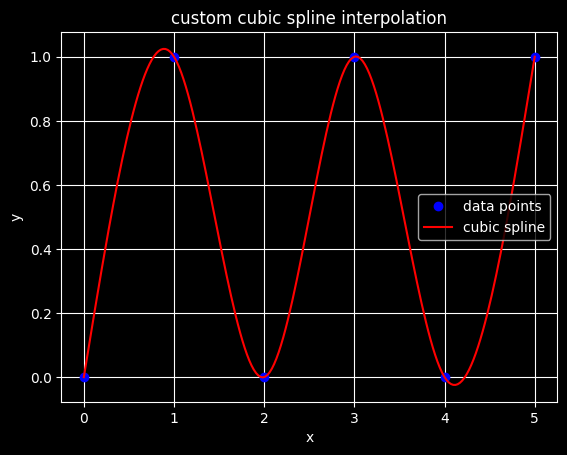

In [2]:
import numpy as np
import math
import time
import matplotlib.pyplot as plt


x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)
#the step size is one the most important parts for this code
h = np.diff(x)

# we must also set up the tridiagnal  system
n = len(x)
A = np.zeros(n - 2)
B = np.zeros(n - 2)
C = np.zeros(n - 2)
D = np.zeros(n - 2)

for i in range(1, n - 1):
    A[i - 1] = h[i - 1]
    B[i - 1] = 2 * (h[i - 1] + h[i])
    C[i - 1] = h[i]
    D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])


def thomas_algorithm(a, b, c, d):
    n = len(b)

    # forward elimination
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x

M_interior = thomas_algorithm(A, B, C, D)

# natural boundary conditions M1 = 0 and Mn = 0
M = np.zeros(n)
M[1:-1] = M_interior

def evaluate_spline(xeval, x, y, M, h):
    y_out = np.zeros(len(xeval))
    for k in range(len(xeval)):
        # find the correct interval
        for i in range(len(x) - 1):
            if x[i] <= xeval[k] <= x[i + 1]:
                # coefficients for cubic polynomial
                a = (M[i + 1] - M[i]) / (6 * h[i])
                b = M[i] / 2
                c = (y[i + 1] - y[i]) / h[i] - h[i] * (2 * M[i] + M[i + 1]) / 6
                d = y[i]
                dx = xeval[k] - x[i]
                y_out[k] = a * dx**3 + b * dx**2 + c * dx + d
                break
    return y_out

# our extra points are strictly for a better visual since the 6 original points will look more like straight lines connecting.
x_interp = np.linspace(x[0], x[-1], 200)
y_interp = evaluate_spline(x_interp, x, y, M, h)


plt.figure()
plt.plot(x, y, "bo", label="data points")
plt.plot(x_interp, y_interp, color="red", label="cubic spline")
plt.xlabel("x")
plt.ylabel("y")
plt.title("custom cubic spline interpolation")
plt.legend()
plt.grid(True)
plt.show()
